Positive sites used for logo: 634


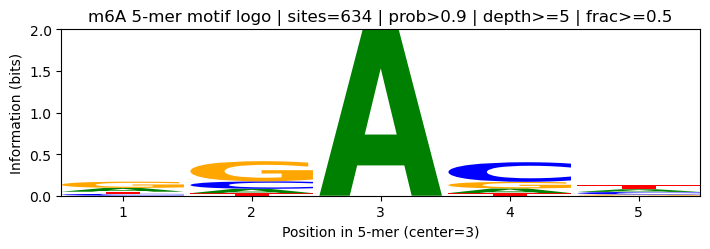

In [ ]:
# Input: /mnt/sunxh/sunxh/project/HEYA8/rep1.m6a.tsv
# Columns (TSV):
#   0 transcript_id, 1 pos, 2 kmer(5-mer), 3 read_id, 4 label, 5 probability

WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.m6a.tsv"
PROB_TH = 0.9
MIN_DEPTH = 5
SITE_POS_FRAC = 0.5
K = 5
site_dict = {}  # id -> [n_hi, n_all]
with open(WT, "r") as f:
    for line in f:
        line = line.rstrip("\n")
        if not line:
            continue
        parts = line.split("\t")
        if len(parts) < 6:
            continue
        tid, pos, kmer = parts[0], parts[1], parts[2].upper()
        if len(kmer) != K:
            continue
        try:
            prob = float(parts[5])
        except ValueError:
            continue
        sid = "|".join([tid, pos, kmer])
        if sid not in site_dict:
            site_dict[sid] = [0, 0]
        if prob > PROB_TH:
            site_dict[sid][0] += 1
        site_dict[sid][1] += 1
pos_kmers = []
for sid, (n_hi, n_all) in site_dict.items():
    if n_all < MIN_DEPTH:
        continue
    if (n_hi / n_all) >= SITE_POS_FRAC:
        pos_kmers.append(sid.split("|")[2])

print(f"Positive sites used for logo: {len(pos_kmers)}")
if len(pos_kmers) == 0:
    raise RuntimeError("pos_kmers为空：请检查阈值/文件列是否正确。")

import pandas as pd
from collections import Counter

alphabet = sorted(set("".join(pos_kmers)))
counts = {ch: [0]*K for ch in alphabet}

for kmer in pos_kmers:
    for i, ch in enumerate(kmer):
        counts[ch][i] += 1

P = pd.DataFrame({ch: counts[ch] for ch in alphabet})
P = P.div(P.sum(axis=1), axis=0).fillna(0.0)

import matplotlib.pyplot as plt

try:
    import logomaker
except ImportError:
    raise ImportError(
        "缺少 logomaker。请在环境里安装：\n"
        "  pip install logomaker\n"
        "或：conda install -c bioconda logomaker"
    )

info_mat = logomaker.transform_matrix(P, from_type="probability", to_type="information")

fig, ax = plt.subplots(figsize=(7.2, 2.6))
logomaker.Logo(info_mat, ax=ax)

ax.set_xlabel("Position in 5-mer (center=3)")
ax.set_ylabel("Information (bits)")
ax.set_xticks(range(K))
ax.set_xticklabels([str(i+1) for i in range(K)])
ax.set_title(f"m6A 5-mer motif logo | sites={len(pos_kmers)} | prob>{PROB_TH} | depth>={MIN_DEPTH} | frac>={SITE_POS_FRAC}")
plt.tight_layout()
plt.show()


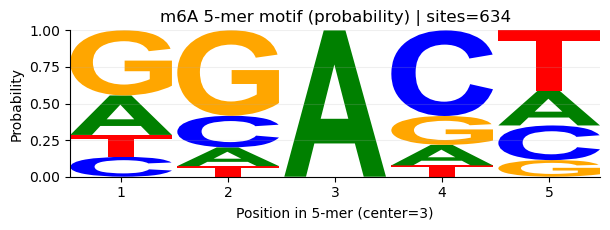

In [42]:
import matplotlib.pyplot as plt
import logomaker

fig, ax = plt.subplots(figsize=(6.2, 2.4))

logo = logomaker.Logo(
    P,
    ax=ax,
    shade_below=0.5,
    fade_below=0.5,
    font_name="Arial",
)

ax.set_ylim(0, 1)

ax.set_xlabel("Position in 5-mer (center=3)")
ax.set_ylabel("Probability")
ax.set_xticks(range(K))
ax.set_xticklabels([str(i+1) for i in range(K)])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

ax.set_title(f"m6A 5-mer motif (probability) | sites={len(pos_kmers)}")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

def collect_pos_kmers_sitelevel(
    WT: str,
    PROB_TH: float = 0.9,
    MIN_DEPTH: int = 5,
    SITE_POS_FRAC: float = 0.5,
    K: int = 5,
    kmer_col: int = 2,
    prob_col: int = 5,
) -> list[str]:
    site_dict = {}  # sid -> [n_hi, n_all]

    with open(WT, "r") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) <= max(kmer_col, prob_col):
                continue

            tid = parts[0]
            pos = parts[1]
            kmer = parts[kmer_col].upper()

            if len(kmer) != K:
                continue

            try:
                prob = float(parts[prob_col])
            except ValueError:
                continue

            sid = "|".join([tid, pos, kmer])
            if sid not in site_dict:
                site_dict[sid] = [0, 0]
            if prob > PROB_TH:
                site_dict[sid][0] += 1
            site_dict[sid][1] += 1

    pos_kmers = []
    for sid, (n_hi, n_all) in site_dict.items():
        if n_all < MIN_DEPTH:
            continue
        if (n_hi / n_all) >= SITE_POS_FRAC:
            pos_kmers.append(sid.split("|")[2])

    return pos_kmers


def plot_probability_logo(
    kmers: list[str],
    K: int = 5,
    title: str | None = None,
    figsize: tuple[float, float] = (4.2, 2.4),
    font_name: str = "Arial",
    shade_below: float = 0.5,
    fade_below: float = 0.5,
):

    if not kmers:
        raise ValueError("kmers为空，无法绘制logo。")
    alphabet = sorted(set("".join(kmers)))
    counts = {ch: [0] * K for ch in alphabet}
    for kmer in kmers:
        if len(kmer) != K:
            raise ValueError(f"发现非{K}-mer: {kmer}")
        for i, ch in enumerate(kmer):
            counts[ch][i] += 1
    P = pd.DataFrame({ch: counts[ch] for ch in alphabet})
    P = P.div(P.sum(axis=1), axis=0).fillna(0.0)
    def _T_to_U_in_P(P: pd.DataFrame) -> pd.DataFrame:
        P = P.copy()
        if "T" in P.columns:
            if "U" in P.columns:
                P["U"] = P["U"] + P["T"]
                P = P.drop(columns=["T"])
            else:
                P = P.rename(columns={"T": "U"})
            P = P.div(P.sum(axis=1), axis=0).fillna(0.0)
        return P
    P = _T_to_U_in_P(P)
    import matplotlib.pyplot as plt
    try:
        import logomaker
    except ImportError:
        raise ImportError(
            "缺少 logomaker。请安装：pip install logomaker 或 conda install -c bioconda logomaker"
        )

    fig, ax = plt.subplots(figsize=figsize)
    logomaker.Logo(
        P,
        ax=ax,
        shade_below=shade_below,
        fade_below=fade_below,
        font_name=font_name,
    )

    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.set_ylabel("Probability")
    ax.set_xticks(range(K))
    ax.set_xticklabels([str(i + 1) for i in range(K)])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

    if title is None:
        title = f"5-mer motif (probability) | N={len(kmers)}"
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return P



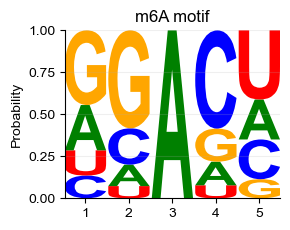

,A,C,G,U
0,0.269716,0.135647,0.444795,0.149842
1,0.127760,0.216088,0.583596,0.072555
2,1.000000,0.000000,0.000000,0.000000
3,0.140379,0.585174,0.197161,0.077287
4,0.238170,0.236593,0.113565,0.411672


In [58]:
def plot_probability_logo(
    kmers: list[str],
    K: int = 5,
    title: str | None = None,
    figsize: tuple[float, float] = (6.2, 2.4),
    font_name: str = "Arial",
    shade_below: float = 0.5,
    fade_below: float = 0.5,
    dna_to_rna: bool = True,
):
    if not kmers:
        raise ValueError("kmers为空，无法绘制logo。")
    import matplotlib as mpl

    mpl.rcParams["font.family"] = "Arial"
    mpl.rcParams["pdf.fonttype"] = 42
    mpl.rcParams["ps.fonttype"]  = 42
    alphabet = sorted(set("".join(kmers)))
    counts = {ch: [0] * K for ch in alphabet}
    for kmer in kmers:
        if len(kmer) != K:
            raise ValueError(f"发现非{K}-mer: {kmer}")
        for i, ch in enumerate(kmer):
            counts[ch][i] += 1

    P = pd.DataFrame({ch: counts[ch] for ch in alphabet})
    P = P.div(P.sum(axis=1), axis=0).fillna(0.0)

    if dna_to_rna and "T" in P.columns:
        if "U" in P.columns:
            P["U"] = P["U"] + P["T"]
            P = P.drop(columns=["T"])
        else:
            P = P.rename(columns={"T": "U"})
        P = P.div(P.sum(axis=1), axis=0).fillna(0.0)

    import matplotlib.pyplot as plt
    try:
        import logomaker
    except ImportError:
        raise ImportError("缺少 logomaker：pip install logomaker 或 conda install -c bioconda logomaker")

    fig, ax = plt.subplots(figsize=figsize)
    logomaker.Logo(P, ax=ax, shade_below=shade_below, fade_below=fade_below, font_name=font_name)

    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.set_ylabel("Probability")
    ax.set_xticks(range(K))
    ax.set_xticklabels([str(i + 1) for i in range(K)])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

    if title is None:
        title = f"5-mer motif (probability) "
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig20_hey8_m6a_motif.pdf", dpi=1200, bbox_inches='tight')
    plt.show()
    return P
WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.m6a.tsv"
kmers = collect_pos_kmers_sitelevel(WT, PROB_TH=0.9, MIN_DEPTH=5, SITE_POS_FRAC=0.5, K=5, )
plot_probability_logo(kmers, K=5, title=f"m6A motif",figsize=(3., 2.4))

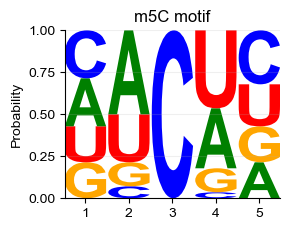

,A,C,G,U
0,0.285714,0.285714,0.214286,0.214286
1,0.500000,0.071429,0.142857,0.285714
2,0.000000,1.000000,0.000000,0.000000
3,0.357143,0.035714,0.142857,0.464286
4,0.214286,0.321429,0.214286,0.250000


In [59]:
def plot_probability_logo(
    kmers: list[str],
    K: int = 5,
    title: str | None = None,
    figsize: tuple[float, float] = (6.2, 2.4),
    font_name: str = "Arial",
    shade_below: float = 0.5,
    fade_below: float = 0.5,
    dna_to_rna: bool = True,
):
    if not kmers:
        raise ValueError("kmers为空，无法绘制logo。")
    import matplotlib as mpl

    mpl.rcParams["font.family"] = "Arial"
    mpl.rcParams["pdf.fonttype"] = 42
    mpl.rcParams["ps.fonttype"]  = 42
    alphabet = sorted(set("".join(kmers)))
    counts = {ch: [0] * K for ch in alphabet}
    for kmer in kmers:
        if len(kmer) != K:
            raise ValueError(f"发现非{K}-mer: {kmer}")
        for i, ch in enumerate(kmer):
            counts[ch][i] += 1

    P = pd.DataFrame({ch: counts[ch] for ch in alphabet})
    P = P.div(P.sum(axis=1), axis=0).fillna(0.0)

    if dna_to_rna and "T" in P.columns:
        if "U" in P.columns:
            P["U"] = P["U"] + P["T"]
            P = P.drop(columns=["T"])
        else:
            P = P.rename(columns={"T": "U"})
        P = P.div(P.sum(axis=1), axis=0).fillna(0.0)

    import matplotlib.pyplot as plt
    try:
        import logomaker
    except ImportError:
        raise ImportError("缺少 logomaker：pip install logomaker 或 conda install -c bioconda logomaker")

    fig, ax = plt.subplots(figsize=figsize)
    logomaker.Logo(P, ax=ax, shade_below=shade_below, fade_below=fade_below, font_name=font_name)

    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.set_ylabel("Probability")
    ax.set_xticks(range(K))
    ax.set_xticklabels([str(i + 1) for i in range(K)])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

    if title is None:
        title = f"5-mer motif (probability) "
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig20_hey8_m5c_motif.pdf", dpi=1200, bbox_inches='tight')
    plt.show()
    return P
WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5c.tsv"
kmers = collect_pos_kmers_sitelevel(WT, PROB_TH=0.95, MIN_DEPTH=10, SITE_POS_FRAC=0.5)
plot_probability_logo(kmers, K=5, title=f"m5C motif", figsize=(3, 2.4))

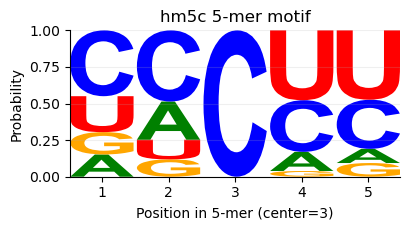

,A,C,G,U
0,0.151958,0.449900,0.152621,0.245521
1,0.260783,0.486397,0.118779,0.134041
2,0.000000,1.000000,0.000000,0.000000
3,0.130723,0.353019,0.039151,0.477107
4,0.096881,0.335766,0.093563,0.473789


In [15]:
WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.hm5c.tsv"
kmers = collect_pos_kmers_sitelevel(WT, PROB_TH=0.95, MIN_DEPTH=10, SITE_POS_FRAC=0.5)
plot_probability_logo(kmers, K=5, title=f"hm5c 5-mer motif")

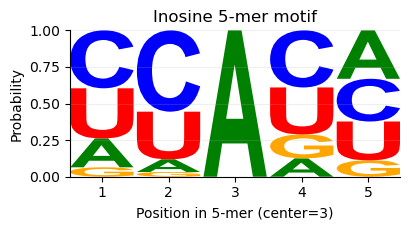

,A,C,G,U
0,0.197307,0.396007,0.064299,0.342386
1,0.086815,0.555710,0.032266,0.325209
2,1.000000,0.000000,0.000000,0.000000
3,0.125580,0.390204,0.163649,0.320566
4,0.331012,0.291783,0.112117,0.265088


In [17]:
WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.Inosine.tsv"
kmers = collect_pos_kmers_sitelevel(WT, PROB_TH=0.95, MIN_DEPTH=10, SITE_POS_FRAC=0.5)
plot_probability_logo(kmers, K=5, title=f"Inosine 5-mer motif")

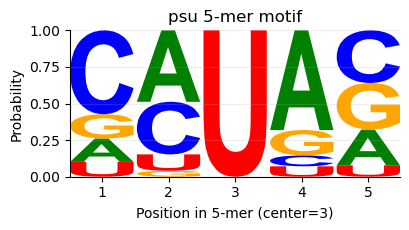

,A,C,G,U
0,0.159322,0.572881,0.166102,0.101695
1,0.488136,0.359322,0.040678,0.111864
2,0.000000,0.000000,0.000000,1.000000
3,0.681356,0.074576,0.172881,0.071186
4,0.244068,0.359322,0.318644,0.077966


In [19]:
WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.psu.tsv"
kmers = collect_pos_kmers_sitelevel(WT, PROB_TH=0.99, MIN_DEPTH=10, SITE_POS_FRAC=0.5)
plot_probability_logo(kmers, K=5, title=f"psu 5-mer motif")

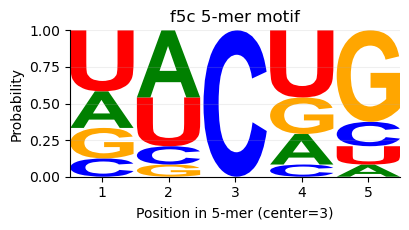

,A,C,G,U
0,0.250000,0.125000,0.208333,0.416667
1,0.458333,0.125000,0.083333,0.333333
2,0.000000,1.000000,0.000000,0.000000
3,0.208333,0.083333,0.250000,0.458333
4,0.083333,0.166667,0.625000,0.125000


In [20]:
WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.f5c.tsv"
kmers = collect_pos_kmers_sitelevel(WT, PROB_TH=0.99, MIN_DEPTH=10, SITE_POS_FRAC=0.5)
plot_probability_logo(kmers, K=5, title=f"f5c 5-mer motif")

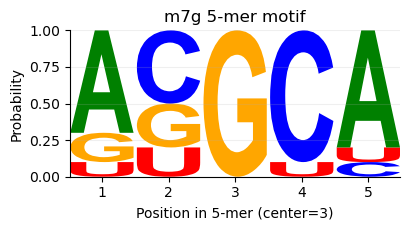

,A,C,G,U
0,0.7,0.0,0.2,0.1
1,0.0,0.5,0.3,0.2
2,0.0,0.0,1.0,0.0
3,0.0,0.9,0.0,0.1
4,0.8,0.1,0.0,0.1


In [22]:
WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.m7g.tsv"
kmers = collect_pos_kmers_sitelevel(WT, PROB_TH=0.99, MIN_DEPTH=10, SITE_POS_FRAC=0.5)
plot_probability_logo(kmers, K=5, title=f"m7g 5-mer motif")

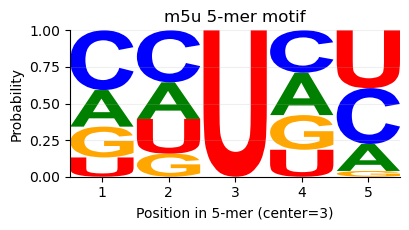

,A,C,G,U
0,0.250000,0.407895,0.210526,0.131579
1,0.250000,0.355263,0.157895,0.236842
2,0.000000,0.000000,0.000000,1.000000
3,0.289474,0.289474,0.236842,0.184211
4,0.184211,0.381579,0.039474,0.394737


In [25]:
WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5u.tsv"
kmers = collect_pos_kmers_sitelevel(WT, PROB_TH=0.95, MIN_DEPTH=10, SITE_POS_FRAC=0.5)
plot_probability_logo(kmers, K=5, title=f"m5u 5-mer motif")

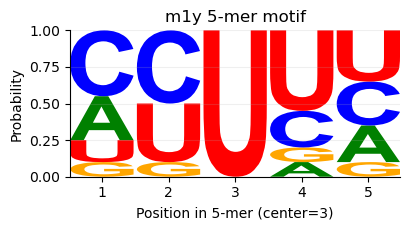

,A,C,G,U
0,0.30,0.45,0.1,0.15
1,0.00,0.50,0.1,0.40
2,0.00,0.00,0.0,1.00
3,0.10,0.25,0.1,0.55
4,0.25,0.30,0.1,0.35


In [27]:
WT = "/mnt/sunxh/sunxh/project/HEYA8/rep1.m1y.tsv"
kmers = collect_pos_kmers_sitelevel(WT, PROB_TH=0.95, MIN_DEPTH=10, SITE_POS_FRAC=0.5)
plot_probability_logo(kmers, K=5, title=f"m1y 5-mer motif")

In [ ]:
import pandas as pd

def build_tx_is_mrna_map(
    gtf_path: str,
    use_transcript_biotype: bool = True,
) -> dict[str, bool]:
    """
    从GTF构建 transcript_id(去版本) -> is_mRNA 的映射。
    你的GTF里有 transcript_biotype / gene_biotype 字段：
      - 默认优先用 transcript_biotype
      - mRNA判定：protein_coding => True，其它 => False

    返回：
      tx2mrna: dict，key为不带版本号的ENST（如 ENST00000456328），value为True/False
    """
    tx2mrna = {}

    def _get_attr(attr_str: str, key: str):
        token = key + ' "'
        i = attr_str.find(token)
        if i == -1:
            return None
        j = attr_str.find('";', i + len(token))
        if j == -1:
            return None
        return attr_str[i + len(token): j]

    with open(gtf_path, "r") as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            feature = parts[2]
            if feature != "transcript":
                continue

            attrs = parts[8]
            tx = _get_attr(attrs, "transcript_id")
            if tx is None:
                continue
            tx_nov = tx.split(".")[0]

            if use_transcript_biotype:
                bio = _get_attr(attrs, "transcript_biotype")
                if bio is None:
                    bio = _get_attr(attrs, "gene_biotype")
            else:
                bio = _get_attr(attrs, "gene_biotype")
                if bio is None:
                    bio = _get_attr(attrs, "transcript_biotype")

            is_mrna = (bio == "protein_coding")
            tx2mrna[tx_nov] = is_mrna

    return tx2mrna


def collect_pos_kmers_sitelevel_split_mrna(
    WT: str,
    tx2mrna: dict[str, bool],
    PROB_TH: float = 0.9,
    MIN_DEPTH: int = 5,
    SITE_POS_FRAC: float = 0.5,
    K: int = 5,
    kmer_col: int = 2,
    prob_col: int = 5,
):
    """
    沿用你现有逻辑（sid=transcript|pos|kmer）做位点聚合，
    但在“位点阳性筛完后”按 mRNA vs 非mRNA 分层输出 kmers。
    返回：
      kmers_mrna, kmers_nonmrna
    """
    site_dict = {}  # sid -> [n_hi, n_all, tx_nov]
    with open(WT, "r") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) <= max(kmer_col, prob_col):
                continue

            tid_raw = parts[0]
            tx_nov = tid_raw.split(".")[0]
            pos = parts[1]
            kmer = parts[kmer_col].upper()
            if len(kmer) != K:
                continue

            try:
                prob = float(parts[prob_col])
            except ValueError:
                continue

            sid = "|".join([tid_raw, pos, kmer])
            if sid not in site_dict:
                site_dict[sid] = [0, 0, tx_nov]
            if prob > PROB_TH:
                site_dict[sid][0] += 1
            site_dict[sid][1] += 1

    kmers_mrna, kmers_nonmrna = [], []
    n_unknown_tx = 0

    for sid, (n_hi, n_all, tx_nov) in site_dict.items():
        if n_all < MIN_DEPTH:
            continue
        if (n_hi / n_all) < SITE_POS_FRAC:
            continue

        kmer = sid.split("|")[2]
        is_mrna = tx2mrna.get(tx_nov, None)
        if is_mrna is None:
            n_unknown_tx += 1
            kmers_nonmrna.append(kmer)
        elif is_mrna:
            kmers_mrna.append(kmer)
        else:
            kmers_nonmrna.append(kmer)

    return kmers_mrna, kmers_nonmrna, n_unknown_tx


def plot_probability_logo(
    kmers: list[str],
    K: int = 5,
    title: str | None = None,
    figsize: tuple[float, float] = (6.2, 2.4),
    font_name: str = "Arial",
    shade_below: float = 0.5,
    fade_below: float = 0.5,
    dna_to_rna: bool = True,
):
    if not kmers:
        raise ValueError("kmers为空，无法绘制logo。")

    alphabet = sorted(set("".join(kmers)))
    counts = {ch: [0] * K for ch in alphabet}
    for kmer in kmers:
        if len(kmer) != K:
            raise ValueError(f"发现非{K}-mer: {kmer}")
        for i, ch in enumerate(kmer):
            counts[ch][i] += 1

    P = pd.DataFrame({ch: counts[ch] for ch in alphabet})
    P = P.div(P.sum(axis=1), axis=0).fillna(0.0)

    if dna_to_rna and "T" in P.columns:
        if "U" in P.columns:
            P["U"] = P["U"] + P["T"]
            P = P.drop(columns=["T"])
        else:
            P = P.rename(columns={"T": "U"})
        P = P.div(P.sum(axis=1), axis=0).fillna(0.0)

    import matplotlib.pyplot as plt
    try:
        import logomaker
    except ImportError:
        raise ImportError("缺少 logomaker：pip install logomaker 或 conda install -c bioconda logomaker")

    fig, ax = plt.subplots(figsize=figsize)
    logomaker.Logo(P, ax=ax, shade_below=shade_below, fade_below=fade_below, font_name=font_name)

    ax.set_ylim(0, 1)
    ax.set_xlabel("Position in 5-mer")
    ax.set_ylabel("Probability")
    ax.set_xticks(range(K))
    ax.set_xticklabels([str(i + 1) for i in range(K)])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

    if title is None:
        title = f"5-mer motif (probability) | N={len(kmers)}"
    ax.set_title(title)

    plt.tight_layout()
    plt.show()
    return P

mRNA kmers: 606
non-mRNA kmers: 28 (unknown_tx_assigned_to_non=11)


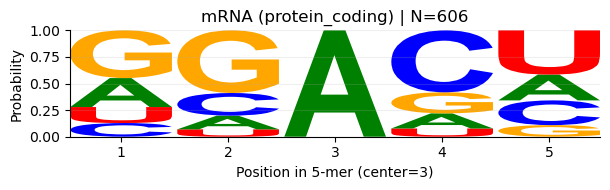

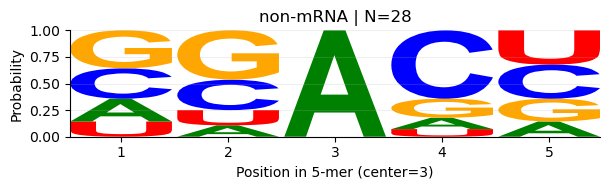

,A,C,G,U
0,0.214286,0.285714,0.357143,0.142857
1,0.107143,0.285714,0.464286,0.142857
2,1.000000,0.000000,0.000000,0.000000
3,0.107143,0.642857,0.178571,0.071429
4,0.142857,0.321429,0.214286,0.321429


In [44]:
GTF = "/mnt/sunxh/sunxh/project/HEYA8/Homo_sapiens.GRCh38.91.gtf"
WT  = "/mnt/sunxh/sunxh/project/HEYA8/rep1.m6a.tsv"
tx2mrna = build_tx_is_mrna_map(GTF)  # transcript_biotype==protein_coding => mRNA
km_mrna, km_non, n_unknown = collect_pos_kmers_sitelevel_split_mrna(
    WT, tx2mrna,
    PROB_TH=0.9, MIN_DEPTH=5, SITE_POS_FRAC=0.5, K=5
)
print(f"mRNA kmers: {len(km_mrna)}")
print(f"non-mRNA kmers: {len(km_non)} (unknown_tx_assigned_to_non={n_unknown})")
plot_probability_logo(km_mrna, K=5, title=f"mRNA (protein_coding) | N={len(km_mrna)}", figsize=(6.2, 2.))
# plot_probability_logo(km_non,  K=5, title=f"non-mRNA | N={len(km_non)}",figsize=(6.2, 2.))

mRNA kmers: 972
non-mRNA kmers: 36 (unknown_tx_assigned_to_non=12)


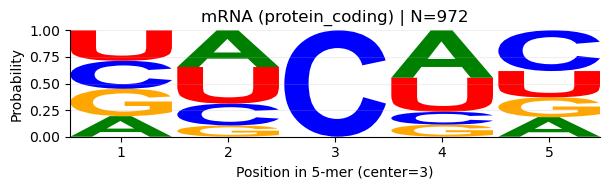

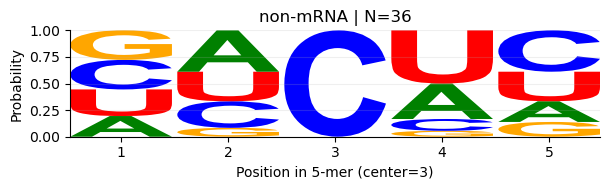

,A,C,G,U
0,0.194444,0.277778,0.277778,0.250000
1,0.388889,0.250000,0.083333,0.277778
2,0.000000,1.000000,0.000000,0.000000
3,0.333333,0.111111,0.055556,0.500000
4,0.194444,0.388889,0.138889,0.277778


In [31]:
GTF = "/mnt/sunxh/sunxh/project/HEYA8/Homo_sapiens.GRCh38.91.gtf"
WT  = "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5c.tsv"
tx2mrna = build_tx_is_mrna_map(GTF)  # transcript_biotype==protein_coding => mRNA
km_mrna, km_non, n_unknown = collect_pos_kmers_sitelevel_split_mrna(
    WT, tx2mrna,
    PROB_TH=0.9, MIN_DEPTH=5, SITE_POS_FRAC=0.5, K=5
)
print(f"mRNA kmers: {len(km_mrna)}")
print(f"non-mRNA kmers: {len(km_non)} (unknown_tx_assigned_to_non={n_unknown})")
plot_probability_logo(km_mrna, K=5, title=f"mRNA (protein_coding) | N={len(km_mrna)}", figsize=(6.2, 2.))
plot_probability_logo(km_non,  K=5, title=f"non-mRNA | N={len(km_non)}",figsize=(6.2, 2.))

mRNA kmers: 5132
non-mRNA kmers: 297 (unknown_tx_assigned_to_non=129)


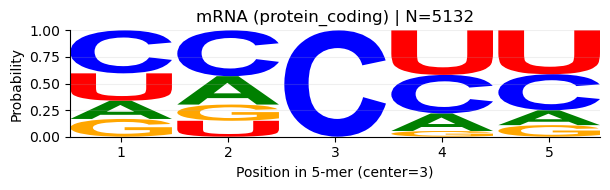

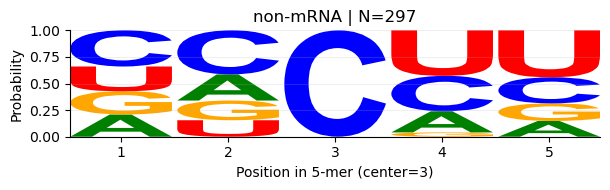

,A,C,G,U
0,0.208754,0.340067,0.218855,0.232323
1,0.245791,0.414141,0.185185,0.154882
2,0.000000,1.000000,0.000000,0.000000
3,0.198653,0.333333,0.040404,0.427609
4,0.148148,0.245791,0.164983,0.441077


In [35]:
GTF = "/mnt/sunxh/sunxh/project/HEYA8/Homo_sapiens.GRCh38.91.gtf"
WT  = "/mnt/sunxh/sunxh/project/HEYA8/rep1.hm5c.tsv"

tx2mrna = build_tx_is_mrna_map(GTF)  # transcript_biotype==protein_coding => mRNA

km_mrna, km_non, n_unknown = collect_pos_kmers_sitelevel_split_mrna(
    WT, tx2mrna,
    PROB_TH=0.95, MIN_DEPTH=5, SITE_POS_FRAC=0.5, K=5
)

print(f"mRNA kmers: {len(km_mrna)}")
print(f"non-mRNA kmers: {len(km_non)} (unknown_tx_assigned_to_non={n_unknown})")

plot_probability_logo(km_mrna, K=5, title=f"mRNA (protein_coding) | N={len(km_mrna)}", figsize=(6.2, 2.))
plot_probability_logo(km_non,  K=5, title=f"non-mRNA | N={len(km_non)}",figsize=(6.2, 2.))

mRNA kmers: 1336
non-mRNA kmers: 34 (unknown_tx_assigned_to_non=16)


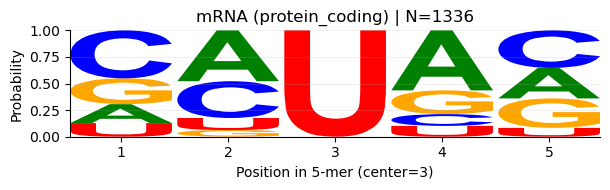

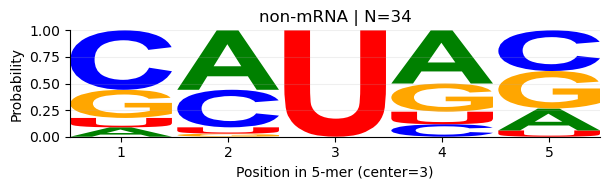

,A,C,G,U
0,0.088235,0.558824,0.264706,0.088235
1,0.558824,0.352941,0.029412,0.058824
2,0.000000,0.000000,0.000000,1.000000
3,0.500000,0.117647,0.264706,0.117647
4,0.205882,0.382353,0.352941,0.058824


In [37]:
GTF = "/mnt/sunxh/sunxh/project/HEYA8/Homo_sapiens.GRCh38.91.gtf"
WT  = "/mnt/sunxh/sunxh/project/HEYA8/rep1.psu.tsv"

tx2mrna = build_tx_is_mrna_map(GTF)  # transcript_biotype==protein_coding => mRNA

km_mrna, km_non, n_unknown = collect_pos_kmers_sitelevel_split_mrna(
    WT, tx2mrna,
    PROB_TH=0.99, MIN_DEPTH=5, SITE_POS_FRAC=0.5, K=5
)

print(f"mRNA kmers: {len(km_mrna)}")
print(f"non-mRNA kmers: {len(km_non)} (unknown_tx_assigned_to_non={n_unknown})")

plot_probability_logo(km_mrna, K=5, title=f"mRNA (protein_coding) | N={len(km_mrna)}", figsize=(6.2, 2.))
plot_probability_logo(km_non,  K=5, title=f"non-mRNA | N={len(km_non)}",figsize=(6.2, 2.))

mRNA kmers: 1606
non-mRNA kmers: 62 (unknown_tx_assigned_to_non=15)


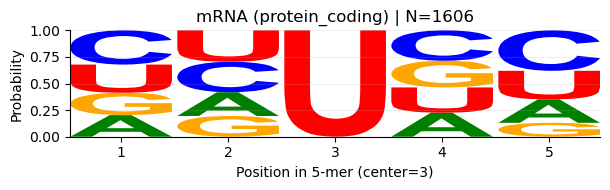

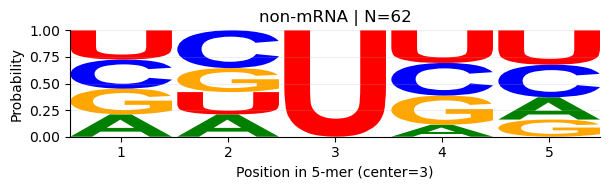

,A,C,G,U
0,0.209677,0.274194,0.241935,0.274194
1,0.209677,0.354839,0.225806,0.209677
2,0.000000,0.000000,0.000000,1.000000
3,0.112903,0.306452,0.274194,0.306452
4,0.209677,0.306452,0.161290,0.322581


In [ ]:
GTF = "/mnt/sunxh/sunxh/project/HEYA8/Homo_sapiens.GRCh38.91.gtf"
WT  = "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5u.tsv"

tx2mrna = build_tx_is_mrna_map(GTF)  # transcript_biotype==protein_coding => mRNA

km_mrna, km_non, n_unknown = collect_pos_kmers_sitelevel_split_mrna(
    WT, tx2mrna,
    PROB_TH=0.95, MIN_DEPTH=5, SITE_POS_FRAC=0.5, K=5
)

print(f"mRNA kmers: {len(km_mrna)}")
print(f"non-mRNA kmers: {len(km_non)} (unknown_tx_assigned_to_non={n_unknown})")

plot_probability_logo(km_mrna, K=5, title=f"mRNA (protein_coding) | N={len(km_mrna)}", figsize=(6.2, 2.))
plot_probability_logo(km_non,  K=5, title=f"non-mRNA | N={len(km_non)}",figsize=(6.2, 2.))

Loaded transcript biotypes: 200310


,layer,mod,N_sites,unknown_tx_assigned_to_non
0,mRNA,psu,11853,205
1,mRNA,m7g,1120,21
2,mRNA,m6a,606,11
3,mRNA,m5u,1606,15
4,mRNA,m5c,972,12
5,mRNA,m1y,431,7
6,mRNA,m1a,500,3
7,mRNA,Inosine,17224,260
8,mRNA,hm5c,12948,296
9,mRNA,f5c,1094,10


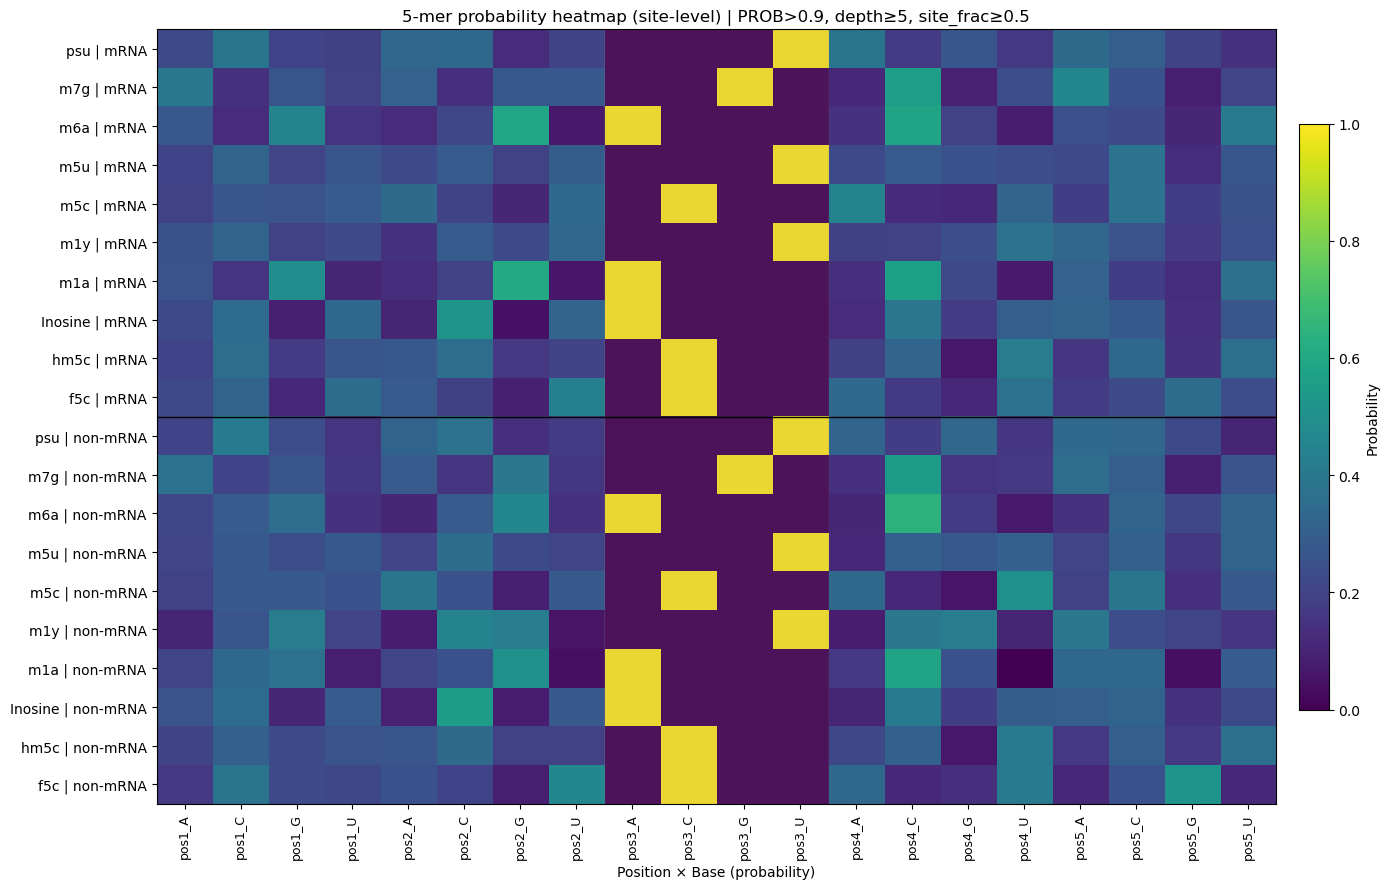

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# =========================
GTF = "/mnt/sunxh/sunxh/project/HEYA8/Homo_sapiens.GRCh38.91.gtf"

PRED_FILES = [
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.psu.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m7g.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m6a.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5u.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5c.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m1y.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m1a.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.Inosine.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.hm5c.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.f5c.tsv",
]

PROB_TH = 0.95
MIN_DEPTH = 10
SITE_POS_FRAC = 0.5
K = 5

KMER_COL = 2
PROB_COL = 5

ALPHABET = ["A", "C", "G", "U"]

# =========================
# 1) GTF: transcript -> is_mRNA（protein_coding）
# =========================
def build_tx_is_mrna_map(gtf_path: str) -> dict[str, bool]:
    def get_attr(attr_str: str, key: str):
        token = key + ' "'
        i = attr_str.find(token)
        if i == -1:
            return None
        j = attr_str.find('";', i + len(token))
        if j == -1:
            return None
        return attr_str[i + len(token): j]

    tx2mrna = {}
    with open(gtf_path, "r") as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            if parts[2] != "transcript":
                continue
            attrs = parts[8]
            tx = get_attr(attrs, "transcript_id")
            if tx is None:
                continue
            tx_nov = tx.split(".")[0]

            bio = get_attr(attrs, "transcript_biotype")
            if bio is None:
                bio = get_attr(attrs, "gene_biotype")

            tx2mrna[tx_nov] = (bio == "protein_coding")
    return tx2mrna

tx2mrna = build_tx_is_mrna_map(GTF)
print("Loaded transcript biotypes:", len(tx2mrna))


# =========================
# =========================
def collect_pos_kmers_sitelevel_split_mrna(
    WT: str,
    tx2mrna: dict[str, bool],
    PROB_TH: float = 0.9,
    MIN_DEPTH: int = 5,
    SITE_POS_FRAC: float = 0.5,
    K: int = 5,
    kmer_col: int = 2,
    prob_col: int = 5,
):
    site_dict = {}  # sid -> [n_hi, n_all, tx_nov]
    with open(WT, "r") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) <= max(kmer_col, prob_col):
                continue

            tid_raw = parts[0]
            tx_nov = tid_raw.split(".")[0]
            pos = parts[1]
            kmer = parts[kmer_col].upper()
            if len(kmer) != K:
                continue

            try:
                prob = float(parts[prob_col])
            except ValueError:
                continue

            sid = "|".join([tid_raw, pos, kmer])
            if sid not in site_dict:
                site_dict[sid] = [0, 0, tx_nov]
            if prob > PROB_TH:
                site_dict[sid][0] += 1
            site_dict[sid][1] += 1

    kmers_mrna, kmers_non = [], []
    n_unknown = 0

    for sid, (n_hi, n_all, tx_nov) in site_dict.items():
        if n_all < MIN_DEPTH:
            continue
        if (n_hi / n_all) < SITE_POS_FRAC:
            continue
        kmer = sid.split("|")[2]
        is_mrna = tx2mrna.get(tx_nov, None)
        if is_mrna is None:
            n_unknown += 1
            kmers_non.append(kmer)
        elif is_mrna:
            kmers_mrna.append(kmer)
        else:
            kmers_non.append(kmer)

    return kmers_mrna, kmers_non, n_unknown


# =========================
# =========================
def kmers_to_prob_vector(kmers: list[str], K: int = 5, alphabet=("A","C","G","U")) -> np.ndarray:
    if not kmers:
        return np.full((K * len(alphabet),), np.nan, dtype=float)

    base2i = {b:i for i,b in enumerate(alphabet)}
    cnt = np.zeros((K, len(alphabet)), dtype=float)

    for kmer in kmers:
        if len(kmer) != K:
            continue
        kmer = kmer.replace("T", "U")
        for p, ch in enumerate(kmer):
            if ch in base2i:
                cnt[p, base2i[ch]] += 1.0

    row_sum = cnt.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        P = cnt / row_sum
    P = np.nan_to_num(P, nan=0.0)

    return P.reshape(-1)  # (K*4,)


# =========================
# =========================
def mod_name_from_path(p: str) -> str:
    fn = os.path.basename(p)
    # rep1.xxx.tsv
    mid = fn.replace("rep1.", "").replace(".tsv", "")
    return mid

mods = [mod_name_from_path(p) for p in PRED_FILES]

cols = []
for pos in range(1, K+1):
    for b in ALPHABET:
        cols.append(f"pos{pos} {b}")

rows = []
mat = []

meta = []  # (layer, mod, n_kmers, n_unknown)

for layer in ["mRNA", "non-mRNA"]:
    for mod, path in zip(mods, PRED_FILES):
        km_mrna, km_non, n_unknown = collect_pos_kmers_sitelevel_split_mrna(
            path, tx2mrna,
            PROB_TH=PROB_TH, MIN_DEPTH=MIN_DEPTH, SITE_POS_FRAC=SITE_POS_FRAC,
            K=K, kmer_col=KMER_COL, prob_col=PROB_COL
        )
        kmers = km_mrna if layer == "mRNA" else km_non
        vec = kmers_to_prob_vector(kmers, K=K, alphabet=ALPHABET)

        rows.append(f"{mod} | {layer}")
        mat.append(vec)
        meta.append((layer, mod, len(kmers), n_unknown))

df = pd.DataFrame(np.vstack(mat), index=rows, columns=cols)

meta_df = pd.DataFrame(meta, columns=["layer","mod","N_sites","unknown_tx_assigned_to_non"])
display(meta_df)


# =========================
# =========================
arr = df.to_numpy(dtype=float)
masked = np.ma.masked_invalid(arr)

fig, ax = plt.subplots(figsize=(14, 9))
im = ax.imshow(masked, aspect="auto")

# x/y ticks
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=9)
ax.set_yticks(np.arange(len(rows)))
ax.set_yticklabels(rows, fontsize=10)

ax.set_xlabel("Position × Base (probability)")
ax.set_title(f"5-mer probability heatmap (site-level)")

center_start = (3 - 1) * 4
center_end = center_start + 4 - 1
ax.axvspan(center_start - 0.5, center_end + 0.5, color="grey", alpha=0.15, zorder=0)

sep = len(mods) - 0.5
ax.axhline(sep, color="black", lw=1.0)

# colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Probability", rotation=90)

plt.tight_layout()
plt.show()


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fa7169c9390>>
Traceback (most recent call last):
  File "/mnt/sunxh/miniconda3/envs/mamba/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


,layer,mod,N_sites,unknown_tx_assigned_to_non
0,mRNA,psu,11853,205
1,mRNA,m7g,1120,21
2,mRNA,m6a,606,11
3,mRNA,m5u,1606,15
4,mRNA,m5c,972,12
5,mRNA,m1y,431,7
6,mRNA,m1a,500,3
7,mRNA,Inosine,17224,260
8,mRNA,hm5c,12948,296
9,mRNA,f5c,1094,10


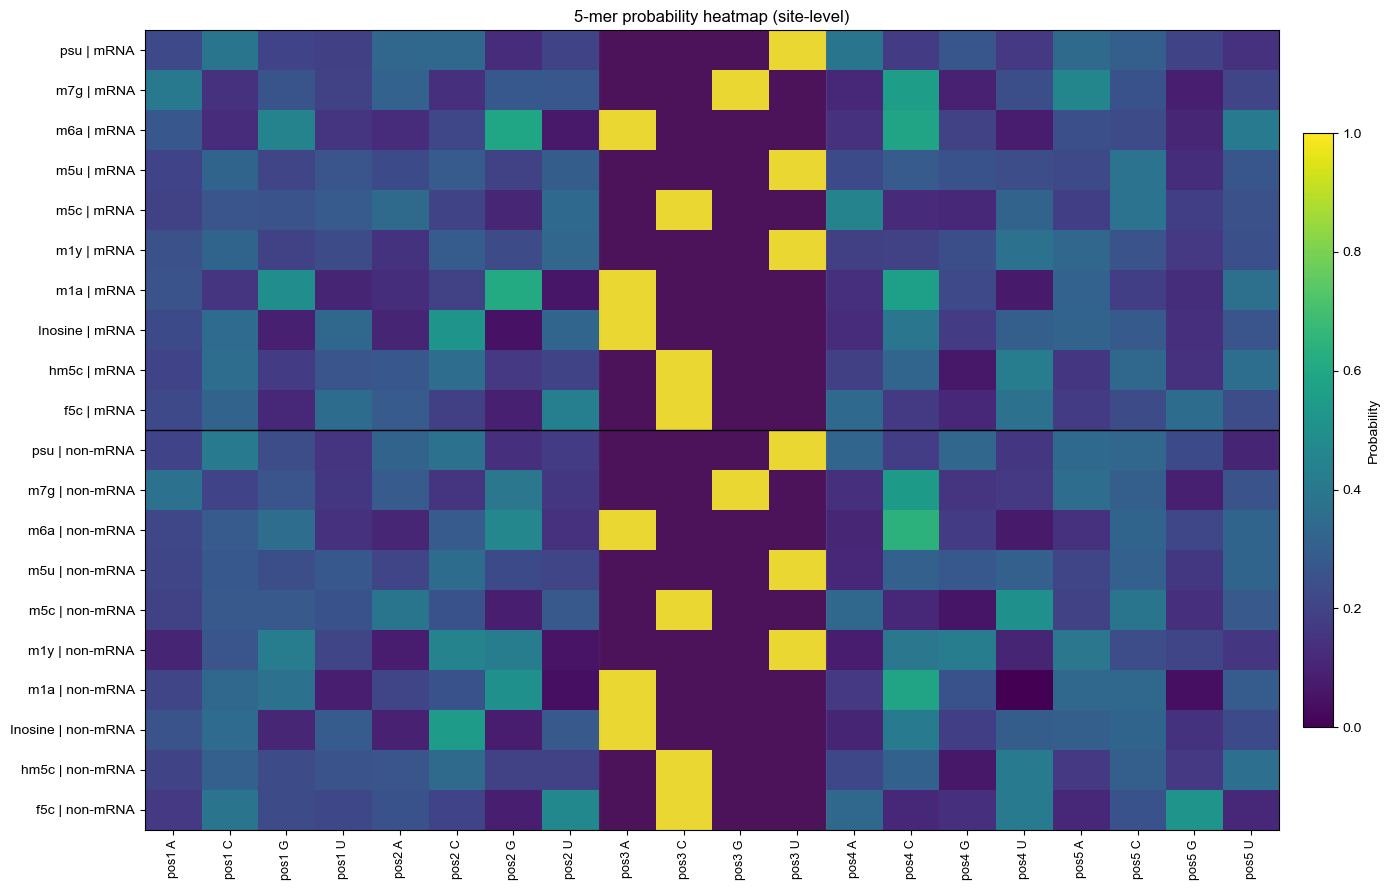

In [54]:
# =========================
# =========================
def mod_name_from_path(p: str) -> str:
    fn = os.path.basename(p)
    # rep1.xxx.tsv
    mid = fn.replace("rep1.", "").replace(".tsv", "")
    return mid

mods = [mod_name_from_path(p) for p in PRED_FILES]

cols = []
for pos in range(1, K+1):
    for b in ALPHABET:
        cols.append(f"pos{pos} {b}")

rows = []
mat = []

meta = []  # (layer, mod, n_kmers, n_unknown)

for layer in ["mRNA", "non-mRNA"]:
    for mod, path in zip(mods, PRED_FILES):
        km_mrna, km_non, n_unknown = collect_pos_kmers_sitelevel_split_mrna(
            path, tx2mrna,
            PROB_TH=PROB_TH, MIN_DEPTH=MIN_DEPTH, SITE_POS_FRAC=SITE_POS_FRAC,
            K=K, kmer_col=KMER_COL, prob_col=PROB_COL
        )
        kmers = km_mrna if layer == "mRNA" else km_non
        vec = kmers_to_prob_vector(kmers, K=K, alphabet=ALPHABET)

        rows.append(f"{mod} | {layer}")
        mat.append(vec)
        meta.append((layer, mod, len(kmers), n_unknown))

df = pd.DataFrame(np.vstack(mat), index=rows, columns=cols)

meta_df = pd.DataFrame(meta, columns=["layer","mod","N_sites","unknown_tx_assigned_to_non"])
display(meta_df)
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"]  = 42
# =========================
# =========================
arr = df.to_numpy(dtype=float)
masked = np.ma.masked_invalid(arr)

fig, ax = plt.subplots(figsize=(14, 9))
im = ax.imshow(masked, aspect="auto")

# x/y ticks
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=9)
ax.set_yticks(np.arange(len(rows)))
ax.set_yticklabels(rows, fontsize=10)

ax.set_xlabel("")
ax.set_title(f"5-mer probability heatmap (site-level)")

center_start = (3 - 1) * 4
center_end = center_start + 4 - 1
ax.axvspan(center_start - 0.5, center_end + 0.5, color="grey", alpha=0.15, zorder=0)

sep = len(mods) - 0.5
ax.axhline(sep, color="black", lw=1.0)

# colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Probability", rotation=90)

plt.tight_layout()

plt.show()
